# ModelTraining
Trains a Random Forest classifier on CleanedData.csv and visualizes results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

DATA_PATH = Path("../CleanedData.csv")
MODEL_PATH = Path("../CyberSecurityModel.pkl")
LABEL_COL = "Label"


## 1. Load cleaned data

In [ ]:
data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
data.head()

Shape: (1145107, 71)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.837199,5.833333e-08,0.000005,0.000000,9.302326e-07,0.000000e+00,0.000242,0.002617,0.001293,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,0.840083,9.416667e-07,0.000000,0.000003,4.651163e-07,9.153974e-09,0.000242,0.002617,0.001293,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,0.840098,4.666667e-07,0.000000,0.000003,4.651163e-07,9.153974e-09,0.000242,0.002617,0.001293,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,0.705527,3.166667e-07,0.000000,0.000003,4.651163e-07,9.153974e-09,0.000242,0.002617,0.001293,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,0.837168,5.833333e-08,0.000005,0.000000,9.302326e-07,0.000000e+00,0.000242,0.002617,0.001293,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


## 2. Visualize class distribution
Log scale because BENIGN dwarfs the attack classes.

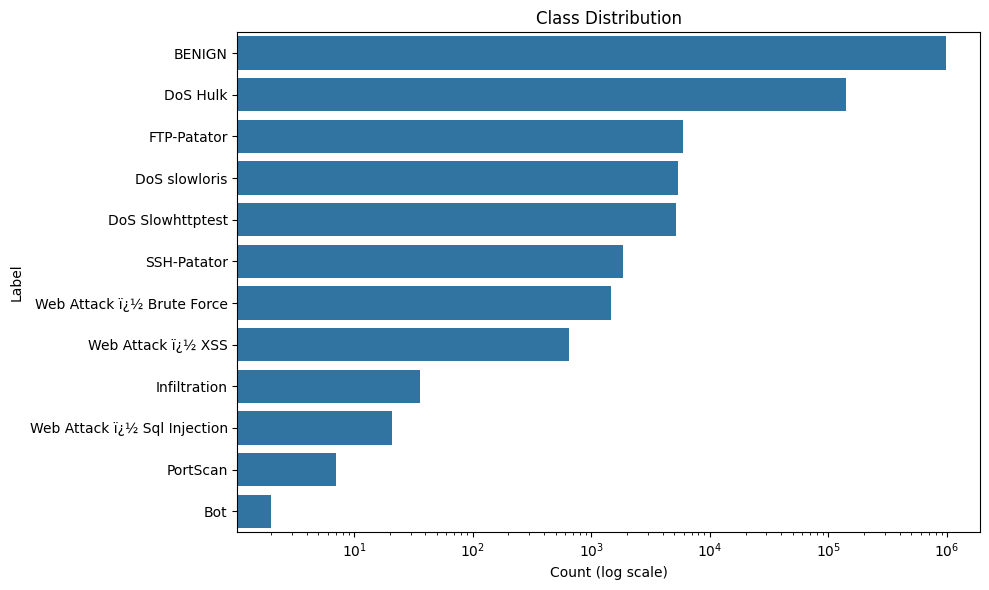

In [ ]:
plt.figure(figsize=(10, 6))
counts = data[LABEL_COL].value_counts()
sns.barplot(x=counts.values, y=counts.index, orient="h")
plt.xscale("log")
plt.xlabel("Count (log scale)")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## 3. Drop classes with too few samples to split/learn from
Anything with fewer than 2 rows can't be stratified; fewer than ~10
is not enough to learn a meaningful pattern either.

In [ ]:
MIN_SAMPLES = 10
class_counts = data[LABEL_COL].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index
dropped = set(class_counts.index) - set(valid_classes)
if dropped:
    print(f"Dropping classes with <{MIN_SAMPLES} samples: {dropped}")
data = data[data[LABEL_COL].isin(valid_classes)]

Dropping classes with <10 samples: {'PortScan', 'Bot'}


## 4. Train-test split

In [ ]:
X = data.drop(columns=[LABEL_COL])
y = data[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (916078, 70) Test: (229020, 70)


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

 ## 6. Evaluate

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9986071085494717

Classification Report:

                              precision    recall  f1-score   support

                      BENIGN       1.00      1.00      1.00    196684
                    DoS Hulk       1.00      1.00      1.00     28217
            DoS Slowhttptest       1.00      1.00      1.00      1046
               DoS slowloris       1.00      0.99      1.00      1077
                 FTP-Patator       1.00      1.00      1.00      1186
                Infiltration       1.00      0.86      0.92         7
                 SSH-Patator       1.00      0.99      0.99       374
  Web Attack ï¿½ Brute Force       0.72      0.79      0.75       294
Web Attack ï¿½ Sql Injection       1.00      0.25      0.40         4
          Web Attack ï¿½ XSS       0.41      0.28      0.33       131

                    accuracy                           1.00    229020
                   macro avg       0.91      0.81      0.84    229020
                weighted avg      

## 7. Confusion matrix

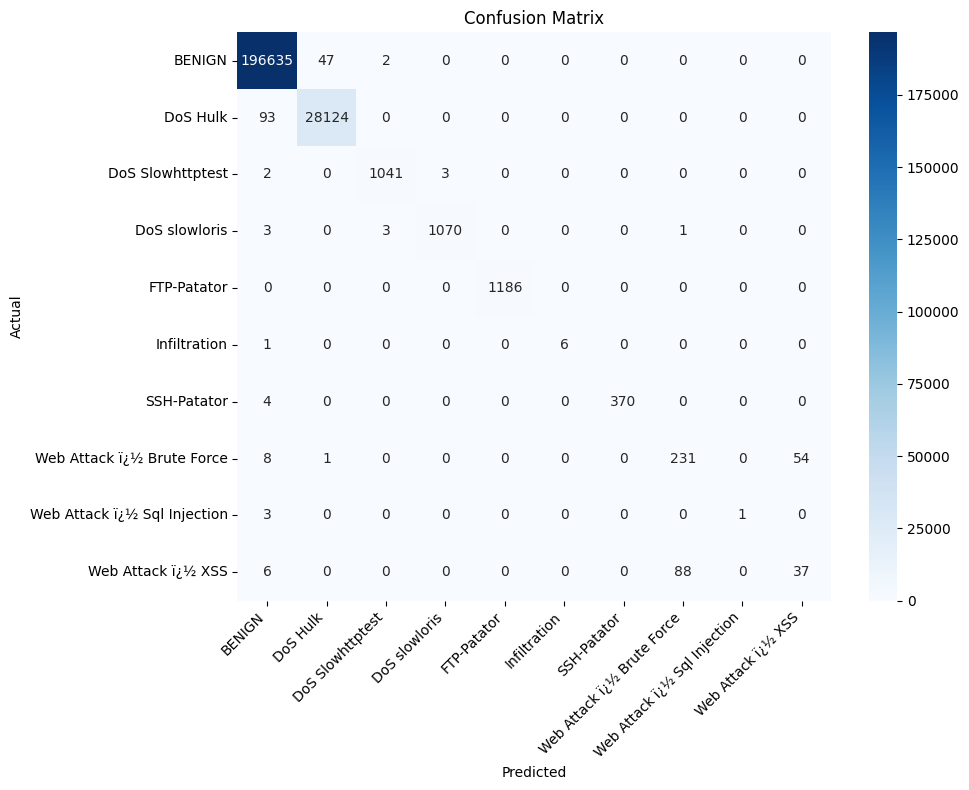

In [ ]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Feature importance
Which flow statistics the model relies on most — useful sanity check
and good material for your project writeup/demo.

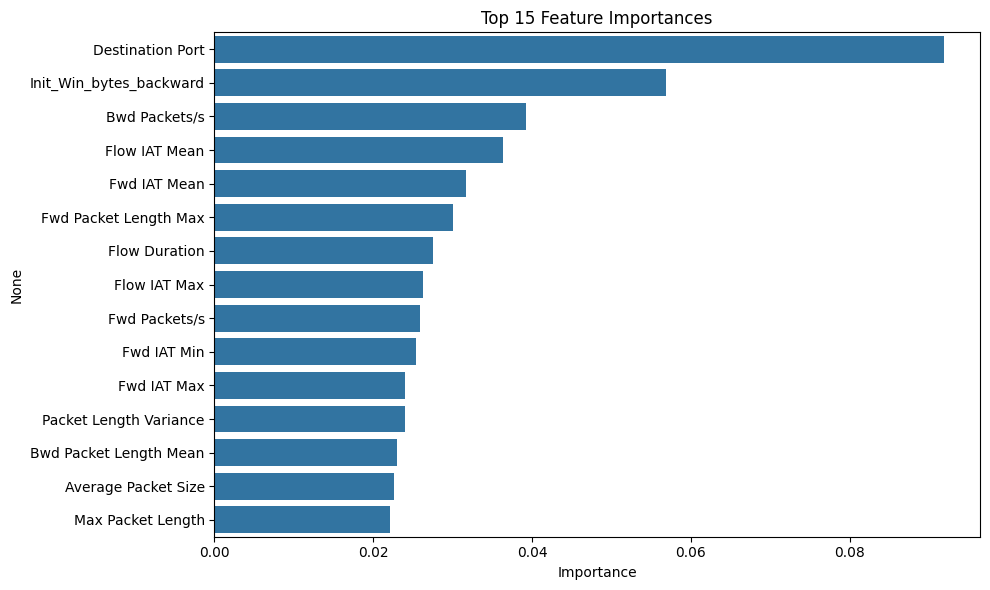

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, orient="h")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to ../CyberSecurityModel.pkl
